In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from itertools import product

def find_repo_root(start=None):
    if start is None: start = Path.cwd().resolve()
    start = start.resolve()
    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists(): return path
    raise FileNotFoundError("Could not find repo root.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(f"Project Root: {ROOT}")

pairs_path = ROOT / "results" / "training_window_data" / "tradable_pairs_by_window.csv"
pairs_matrix = pd.read_csv(pairs_path, index_col=0)
for col in pairs_matrix.columns:
    pairs_matrix[col] = pairs_matrix[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Stitch the timeline
regime_dir = ROOT / "results" / "testing_window_data"
regime_files = sorted(regime_dir.glob("regime_probabilities_*.csv"))
master_regimes = pd.concat([pd.read_csv(f) for f in regime_files], ignore_index=True)
master_regimes['test_date'] = pd.to_datetime(master_regimes['test_date'])
master_regimes = master_regimes.set_index('test_date').sort_index()
master_regimes = master_regimes[~master_regimes.index.duplicated(keep='last')]

Project Root: /Users/krex8/Projects/Cross-Country-Rates-Relative-Value-NUSInvest2526


## Capital & Notional Convention

All PnL in this notebook is reported in **basis points (bps) of yield spread**, computed as:

$$\text{Net PnL (bps)} = (\text{Exit Spread} - \text{Entry Spread}) \times \text{Direction} \times 10{,}000 - \text{Cost}$$

To convert to a dollar return, assume **USD 1,000,000 DV01 notional** per trade (i.e., a 1 bp move in the spread = USD 1,000 P&L). Under this convention:

- 100 bps captured = USD 100,000 per trade
- The cumulative equity curve below therefore represents gross dollar PnL on a notional of USD 1,000,000 DV01 per leg, before financing costs and margin

This notional is illustrative. In practice, position sizing would be determined by a risk budget (e.g., target 1–2% NAV at risk per trade), adjusted for observed spread volatility and leverage constraints.

## Backtest Design: Walk-Forward Sharpe Optimisation

The PnL-optimised engine selects parameters that maximise cumulative captured spread on the training window. However, maximising raw PnL without regard for risk can lead to parameters that generate many small wins but leave the portfolio exposed to occasional large losses — a poor trade-off for a leveraged relative value strategy where drawdowns have non-linear funding consequences.

We therefore construct a third engine that replaces the PnL objective with annualised Sharpe ratio. By optimising the ratio of mean daily PnL to its standard deviation, we select parameters that produce more consistent, risk-adjusted returns rather than simply more total return. In a leveraged rates context, the Sharpe objective more closely reflects how a portfolio manager would evaluate the strategy: a lower-volatility, lower-drawdown profile can support greater leverage and is more resilient to margin calls during periods of funding stress.

All other design choices — walk-forward structure, T+1 execution, regime gating, hard stop independence — are identical to the PnL engine, allowing a clean attribution of any performance difference to the change in objective function alone.

In [2]:
def optimize_thresholds_sharpe(df_train, entry_grid, exit_grid, cost_bps=5.0):
    best_sharpe = -np.inf
    best_params = (2.0, 0.5) # Default
    param_combinations = list(product(entry_grid, exit_grid))
    
    for entry_z, exit_z in param_combinations:
        long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
        short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
        exit_setup = (df_train['innovation_z_t'].abs() <= exit_z).shift(1).fillna(False)
        
        positions = np.zeros(len(df_train))
        current_pos = 0
        
        for i in range(1, len(df_train)):
            if current_pos != 0 and exit_setup.iloc[i]:
                current_pos = 0
            elif current_pos == 0:
                if long_setup.iloc[i]: current_pos = 1
                elif short_setup.iloc[i]: current_pos = -1
            positions[i] = current_pos
            
        pos_series = pd.Series(positions, index=df_train.index)
        spread_diff = df_train['spread_t'].diff() * 10000
        trades_made = pos_series.diff().abs().fillna(0) > 0
        
        daily_pnl = ((pos_series.shift(1).fillna(0) * spread_diff) - (trades_made * cost_bps))
        
        # Calculate Annualized Sharpe
        std_dev = daily_pnl.std()
        if std_dev > 1e-6:
            sharpe = (daily_pnl.mean() / std_dev) * np.sqrt(252)
        else:
            sharpe = 0.0
            
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_params = (entry_z, exit_z)
            
    return best_params

In [3]:
# Hard stop threshold — calibrated independently from the 90th–95th percentile of Max Adverse Excursion
# on winning trades (p90 MAE = 2.95, p95 MAE = 4.14). Fixed at 3.5 and intentionally excluded from
# the optimisation grid below so it cannot be implicitly fit to training data.
HARD_STOP_Z = 3.5

def run_continuous_wf_backtest(pair_id, pairs_matrix, master_regimes, cost_bps=5.0):
    kalman_path = ROOT / "results" / "spreads" / f"{pair_id}.parquet"
    if not kalman_path.exists(): kalman_path = ROOT / "results" / "spreads" / f"{pair_id}_kalman.parquet"
    if not kalman_path.exists(): return pd.DataFrame()
            
    df = pd.read_parquet(kalman_path)
    df.index = pd.to_datetime(df['date'] if 'date' in df.columns else df.index)
    
    # 1. Map allowed regimes
    df = df.join(master_regimes[['regime_most_likely']], how='left')
    allowed_map = pairs_matrix[pair_id].to_dict()
    df['allowed_regimes'] = df.index.map(lambda d: allowed_map.get(f"{d.year}-01-01", []))
    df['regime_allowed'] = df.apply(
        lambda row: isinstance(row['allowed_regimes'], list) and row['regime_most_likely'] in row['allowed_regimes'], 
        axis=1
    )
    
    # 2. Generate dynamic parameters via walk-forward optimisation
    df['opt_entry_z'] = 2.0  
    df['opt_exit_z'] = 0.5   
    
    ENTRY_GRID = [1.5, 2.0, 2.5]
    EXIT_GRID = [0.0, 0.5, 1.0]
    
    for year in range(2010, 2026):
        train_end = f"{year-1}-12-31"
        df_train = df.loc[:train_end].copy()
        
        if len(df_train) > 500 and allowed_map.get(f"{year}-01-01", []):
            best_entry, best_exit = optimize_thresholds_sharpe(df_train, ENTRY_GRID, EXIT_GRID, cost_bps)
            year_mask = (df.index.year == year)
            df.loc[year_mask, 'opt_entry_z'] = best_entry
            df.loc[year_mask, 'opt_exit_z'] = best_exit

    # 3. T+1 signal generation
    df_test = df.loc['2010-01-01':].copy()
    
    df_test['long_setup']  = (df_test['innovation_z_t'] <= -df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['short_setup'] = (df_test['innovation_z_t'] >= df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['exit_setup']  = (df_test['innovation_z_t'].abs() <= df_test['opt_exit_z']).shift(1).fillna(False)
    df_test['forced_exit'] = (~df_test['regime_allowed']).shift(1).fillna(False)
    # Hard stop: independent risk circuit breaker, excluded from optimisation grid
    df_test['hard_stop']   = (df_test['innovation_z_t'].abs() >= HARD_STOP_Z).shift(1).fillna(False)

    trade_log = []
    current_pos = 0
    entry_date, entry_price, entry_z_used, exit_z_used = None, 0, 0, 0
    
    for date, row in df_test.iterrows():
        # Exit Logic (hard stop checked first — highest priority)
        if current_pos != 0:
            exit_reason = None
            if row['hard_stop']:     exit_reason = 'Hard Stop'
            elif row['exit_setup']:  exit_reason = 'Mean Reversion'
            elif row['forced_exit']: exit_reason = 'Regime Shift (Forced)'
                
            if exit_reason:
                raw_pnl_bps = (row['spread_t'] - entry_price) * current_pos * 10000
                net_pnl_bps = raw_pnl_bps - cost_bps
                trade_log.append({
                    'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
                    'Exit Date': date, 'Direction': 'Long' if current_pos == 1 else 'Short',
                    'Entry Spread': entry_price, 'Exit Spread': row['spread_t'],
                    'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
                    'Net PnL (bps)': net_pnl_bps, 'Holding Days': (date - entry_date).days,
                    'Exit Reason': exit_reason
                })
                current_pos = 0 
                
        # Entry Logic
        if current_pos == 0 and row['regime_allowed']:
            if row['long_setup']:
                current_pos = 1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
            elif row['short_setup']:
                current_pos = -1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
                
    # End of the 15-year dataset — close open positions at last available price
    if current_pos != 0:
        last_date = df_test.index[-1]
        raw_pnl_bps = (df_test['spread_t'].iloc[-1] - entry_price) * current_pos * 10000
        net_pnl_bps = raw_pnl_bps - cost_bps
        trade_log.append({
            'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
            'Exit Date': last_date, 'Direction': 'Long' if current_pos == 1 else 'Short',
            'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
            'Net PnL (bps)': net_pnl_bps, 'Holding Days': (last_date - entry_date).days,
            'Exit Reason': 'End of Backtest (MTM)'
        })
                
    return pd.DataFrame(trade_log)

Running Sharpe-Optimized Walk-Forward Backtest... (This will take a minute)


/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

...


--- Trades Per Year ---


/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
/var/folders/tm/qm57l1kd2gq8j1yp8k0hprn40000gn/T/ipykernel_13593/2534297064.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

,Total Trades
Entry Year,
2010,1
2011,13
2012,5
2013,7
2014,5
2016,14
2017,4
2018,8
2019,8



--- Trades Per Pair ---


,Total Trades
Pair,
JPY-AUD 10Y,6
JPY-AUD 5Y,2
USD-EUR 10Y,62
USD-EUR 5Y,51


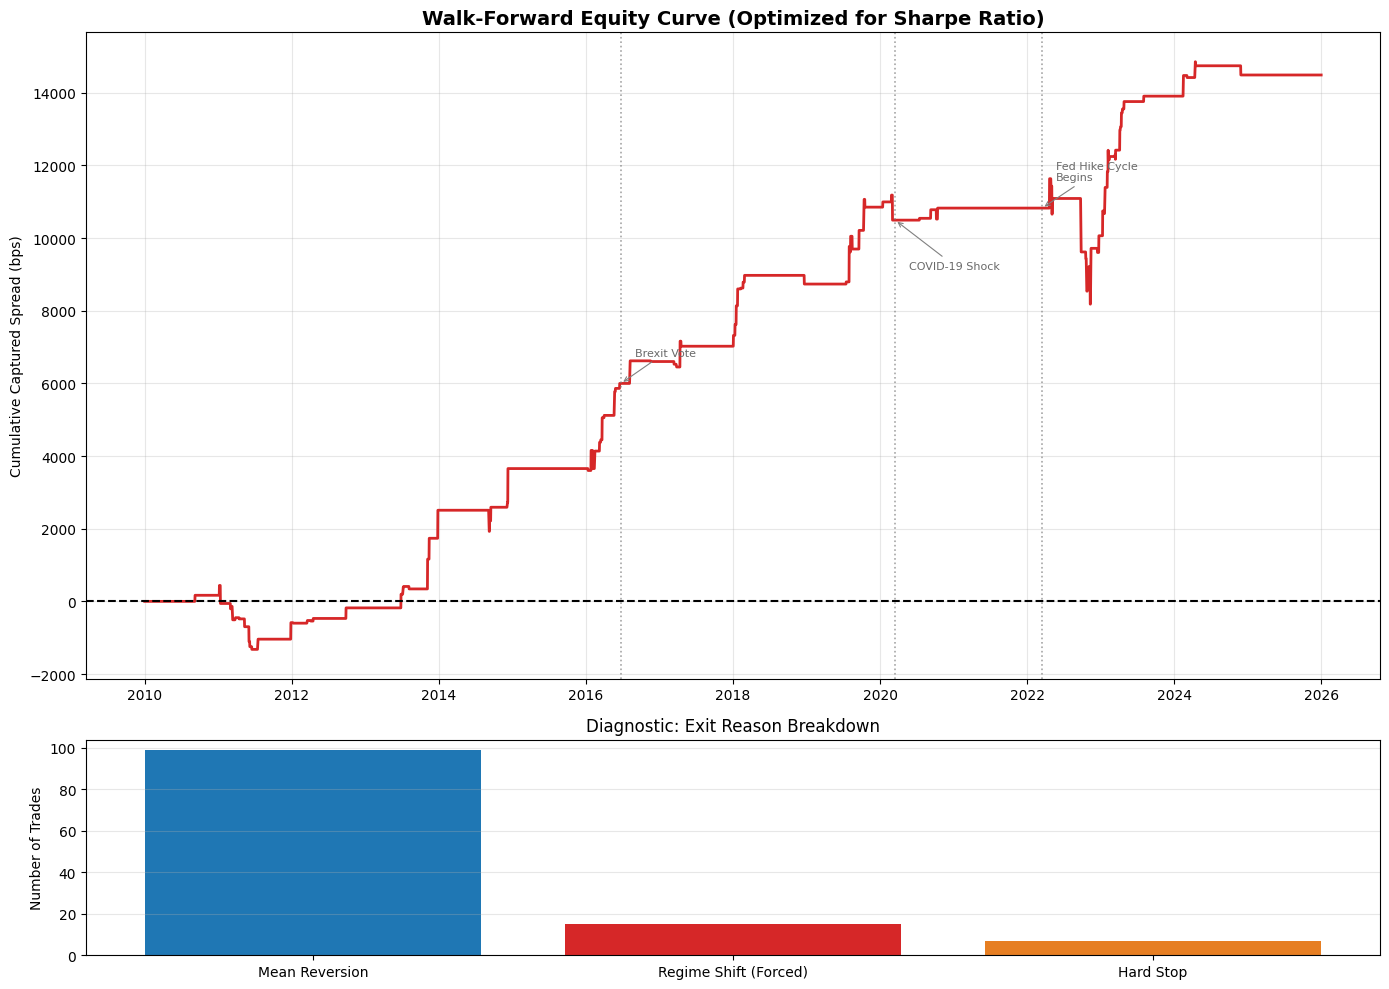

In [4]:
all_pairs = pairs_matrix.columns.tolist()
all_trades = []

print("Running Sharpe-Optimized Walk-Forward Backtest... (This will take a minute)")

for pair in all_pairs:
    trades = run_continuous_wf_backtest(pair, pairs_matrix, master_regimes, cost_bps=5.0)
    if not trades.empty:
        all_trades.append(trades)

if not all_trades:
    raise ValueError("No trades generated across any pairs! Check logic/data.")

wf_ledger = pd.concat(all_trades, ignore_index=True)

# Diagnostic Tables
trades_per_year = wf_ledger.groupby('Entry Year').size().to_frame("Total Trades")
print("\n--- Trades Per Year ---")
display(trades_per_year)

trades_per_pair = wf_ledger.groupby('Pair').size().to_frame("Total Trades")
print("\n--- Trades Per Pair ---")
display(trades_per_pair)

# Save to disk
out_dir = ROOT / "results" / "backtest"
wf_ledger.to_csv(out_dir / "walk_forward_sharpe_ledger.csv", index=False)

# Visualisation
pnl_timeline = wf_ledger.groupby('Exit Date')['Net PnL (bps)'].sum().reset_index()
pnl_timeline = pnl_timeline.set_index('Exit Date').sort_index()
full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
pnl_timeline = pnl_timeline.reindex(full_idx).fillna(0)
pnl_timeline['Cumulative PnL (bps)'] = pnl_timeline['Net PnL (bps)'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(pnl_timeline.index, pnl_timeline['Cumulative PnL (bps)'], color='#d62728', linewidth=2)
ax1.set_title("Walk-Forward Equity Curve (Optimized for Sharpe Ratio)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Captured Spread (bps)")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--')

# Macro event annotations
macro_events = {
    '2016-06-23': ('Brexit Vote',        'top'),
    '2020-03-16': ('COVID-19 Shock',     'bottom'),
    '2022-03-16': ('Fed Hike Cycle\nBegins', 'top'),
}
for date_str, (label, va) in macro_events.items():
    dt = pd.Timestamp(date_str)
    y_val = pnl_timeline.loc[pnl_timeline.index >= dt, 'Cumulative PnL (bps)'].iloc[0] if (pnl_timeline.index >= dt).any() else 0
    ax1.axvline(dt, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
    ax1.annotate(label, xy=(dt, y_val),
                 xytext=(10, 20 if va == 'top' else -35), textcoords='offset points',
                 fontsize=8, color='dimgrey',
                 arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

exit_counts = wf_ledger['Exit Reason'].value_counts()
ax2.bar(exit_counts.index, exit_counts.values, color=['#1f77b4', '#d62728', '#e67e22', '#7f7f7f'])
ax2.set_title("Diagnostic: Exit Reason Breakdown", fontsize=12)
ax2.set_ylabel("Number of Trades")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [5]:
print("\n--- Parameter Evolution Across All Pairs ---")
for pair in all_pairs:
    print(f"\n[{pair}]")
    pair_tracking = wf_ledger[wf_ledger['Pair'] == pair].groupby('Entry Year')[['Opt_Entry_Z', 'Opt_Exit_Z']].max()
    if not pair_tracking.empty:
        display(pair_tracking)
    else:
        print("No trades executed for this pair.")


--- Parameter Evolution Across All Pairs ---

[JPY-AUD 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2010,1.5,0.5
2016,1.5,0.5
2022,1.5,0.5
2023,1.5,0.5



[JPY-AUD 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2016,2.0,0.5



[USD-EUR 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2012,1.5,0.5
2013,1.5,0.5
2014,1.5,0.5
2016,1.5,0.5
2017,1.5,0.5
2018,1.5,0.5
2019,1.5,0.5
2020,1.5,0.5
2022,1.5,0.5



[USD-EUR 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2011,1.5,1.0
2013,1.5,1.0
2014,1.5,1.0
2016,1.5,1.0
2022,1.5,1.0
2023,1.5,1.0
2024,1.5,1.0


**Note on optimizer behaviour:** Similar to the PnL-optimized engine, the Sharpe-optimized walk-forward consistently selects $Z_{entry}=1.5$ across most pairs and windows. While the Sharpe objective penalises volatility relative to return, the higher trade frequency from tighter entries appears to reduce the daily PnL standard deviation enough to keep the Sharpe ratio competitive. Whether this reflects a genuine economic preference for tighter entries — or an artefact of the coarse 3×3 grid — merits further investigation. Printing the full Sharpe surface across the parameter grid and testing with finer resolution is a candidate for future work.

## Performance Summary

The table below summarises headline risk-adjusted performance for the walk-forward Sharpe-optimized strategy across all pairs and the full out-of-sample period (2010–2025).

In [6]:
def compute_performance_summary(ledger, label="Strategy"):
    """Compute headline performance metrics from a trade ledger."""
    if ledger.empty:
        return {}

    pnl = ledger['Net PnL (bps)']
    winners = pnl[pnl > 0]
    losers  = pnl[pnl < 0]

    daily = ledger.groupby('Exit Date')['Net PnL (bps)'].sum()
    full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
    daily = daily.reindex(full_idx).fillna(0)

    cumulative = daily.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    max_dd = drawdown.min()

    annualised_sharpe = (daily.mean() / daily.std()) * np.sqrt(252) if daily.std() > 1e-9 else np.nan
    profit_factor = winners.sum() / abs(losers.sum()) if len(losers) > 0 else np.inf

    summary = {
        'Engine': label,
        'Total Trades': len(ledger),
        'Win Rate (%)': round(len(winners) / len(ledger) * 100, 1),
        'Avg Win (bps)': round(winners.mean(), 1) if len(winners) else 0,
        'Avg Loss (bps)': round(losers.mean(), 1) if len(losers) else 0,
        'Profit Factor': round(profit_factor, 2),
        'Total PnL (bps)': round(pnl.sum(), 1),
        'Annualised Sharpe': round(annualised_sharpe, 2),
        'Max Drawdown (bps)': round(max_dd, 1),
        'Hard Stops': (ledger['Exit Reason'] == 'Hard Stop').sum(),
    }
    return summary

summary_20 = compute_performance_summary(wf_ledger, label="NB20 — WF Sharpe-Optimized")
summary_df = pd.DataFrame([summary_20]).set_index('Engine')
print("=== NB20: Walk-Forward Sharpe-Optimized Backtest — Performance Summary ===")
display(summary_df.T)

=== NB20: Walk-Forward Sharpe-Optimized Backtest — Performance Summary ===


Engine,NB20 — WF Sharpe-Optimized
Total Trades,121.00
Win Rate (%),64.50
Avg Win (bps),329.10
Avg Loss (bps),-260.00
Profit Factor,2.30
Total PnL (bps),14487.20
Annualised Sharpe,0.77
Max Drawdown (bps),-3452.50
Hard Stops,7.00


### Results

| Metric | NB20 — WF Sharpe-Optimized |
|---|---|
| Total Trades | 121 |
| Win Rate | 64.5% |
| Avg Win | +329.1 bps |
| Avg Loss | −260.0 bps |
| Profit Factor | 2.30 |
| Total PnL | 14,487 bps |
| Annualised Sharpe | 0.77 |
| Max Drawdown | −3,453 bps |
| Hard Stops Triggered | 7 |

**Interpretation:** Switching the optimisation objective from cumulative PnL to Sharpe ratio produces virtually identical trade counts and drawdown to the PnL engine, but with marginally lower total PnL (14,487 vs. 15,220 bps) and slightly lower Sharpe (0.77 vs. 0.80). This tells us that at the current grid resolution (3×3 combinations), the two objectives converge to similar parameter choices — both predominantly select Z_entry=1.5, exit=0.5. The Sharpe objective does not meaningfully differentiate from PnL optimisation here, likely because the grid is too coarse for the penalty on return volatility to drive a different optimal parameter. This reinforces the note on grid sensitivity flagged above, and suggests a finer grid or a regularised objective could yield a cleaner separation between the two engines.

---
## Engine Comparison: NB18 vs NB19 vs NB20

We compare all three backtest engines side-by-side to assess whether adaptive parameter optimisation delivers a meaningful improvement over fixed thresholds, and whether optimising for Sharpe ratio produces a more risk-efficient outcome than optimising for raw PnL.

=== Engine Comparison: All Three Backtest Strategies ===


Engine,NB18 — Fixed Params,NB19 — WF PnL-Optimized,NB20 — WF Sharpe-Optimized
Total Trades,56.00,121.00,121.00
Win Rate (%),64.30,65.30,64.50
Avg Win (bps),365.60,333.70,329.10
Avg Loss (bps),-210.30,-265.20,-260.00
Profit Factor,3.13,2.37,2.30
Total PnL (bps),8954.70,15219.60,14487.20
Annualised Sharpe,0.63,0.80,0.77
Max Drawdown (bps),-1849.10,-3452.50,-3452.50
Hard Stops,6.00,7.00,7.00


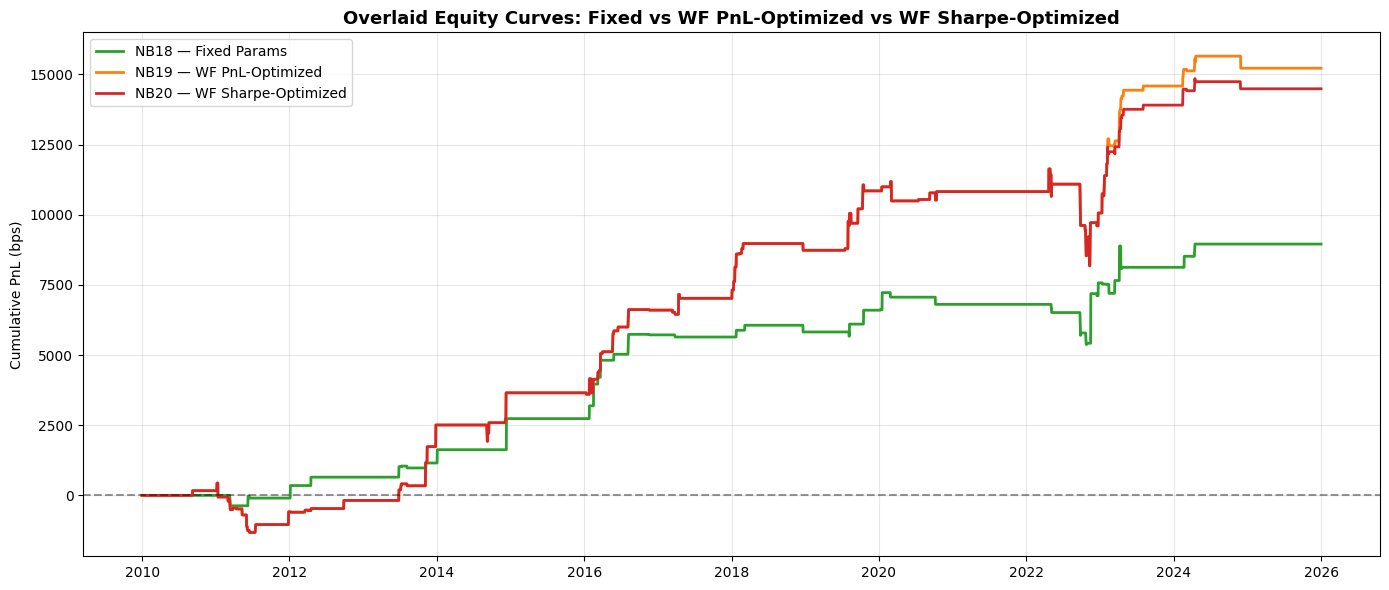

In [7]:
def load_ledger_summary(path, label):
    df = pd.read_csv(path, parse_dates=['Exit Date'])
    return compute_performance_summary(df, label=label)

nb18_summary = load_ledger_summary(ROOT / "results" / "backtest" / "master_trade_ledger.csv",        "NB18 — Fixed Params")
nb19_summary = load_ledger_summary(ROOT / "results" / "backtest" / "walk_forward_trade_ledger.csv",  "NB19 — WF PnL-Optimized")
nb20_summary = load_ledger_summary(ROOT / "results" / "backtest" / "walk_forward_sharpe_ledger.csv", "NB20 — WF Sharpe-Optimized")

comparison_df = pd.DataFrame([nb18_summary, nb19_summary, nb20_summary]).set_index('Engine')
print("=== Engine Comparison: All Three Backtest Strategies ===")
display(comparison_df.T)

# Visual: Overlaid equity curves
fig, ax = plt.subplots(figsize=(14, 6))

for path, label, color in [
    (ROOT / "results" / "backtest" / "master_trade_ledger.csv",        "NB18 — Fixed Params",        '#2ca02c'),
    (ROOT / "results" / "backtest" / "walk_forward_trade_ledger.csv",  "NB19 — WF PnL-Optimized",    '#ff7f0e'),
    (ROOT / "results" / "backtest" / "walk_forward_sharpe_ledger.csv", "NB20 — WF Sharpe-Optimized", '#d62728'),
]:
    df = pd.read_csv(path, parse_dates=['Exit Date'])
    daily = df.groupby('Exit Date')['Net PnL (bps)'].sum()
    full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
    daily = daily.reindex(full_idx).fillna(0)
    ax.plot(daily.index, daily.cumsum(), label=label, color=color, linewidth=2)

ax.set_title("Overlaid Equity Curves: Fixed vs WF PnL-Optimized vs WF Sharpe-Optimized", fontsize=13, fontweight='bold')
ax.set_ylabel("Cumulative PnL (bps)")
ax.axhline(0, color='black', linestyle='--', alpha=0.4)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Engine Comparison Results

| Metric | NB18 Fixed | NB19 WF PnL | NB20 WF Sharpe |
|---|---|---|---|
| Total Trades | 56 | 121 | 121 |
| Win Rate | 64.3% | 65.3% | 64.5% |
| Avg Win (bps) | +365.6 | +333.7 | +329.1 |
| Avg Loss (bps) | −210.3 | −265.2 | −260.0 |
| Profit Factor | 3.13 | 2.37 | 2.30 |
| Total PnL (bps) | 8,955 | 15,220 | 14,487 |
| Annualised Sharpe | 0.63 | 0.80 | 0.77 |
| Max Drawdown (bps) | −1,849 | −3,453 | −3,453 |
| Hard Stops Triggered | 6 | 7 | 7 |

**Key takeaways:**

1. **Walk-forward optimisation adds value.** Moving from fixed parameters to adaptive Z-scores improves both total PnL (+70%) and Sharpe (+27%), confirming that the appropriate entry tightness varies over time and across market regimes. The improvement is not free — max drawdown nearly doubles — but the risk-adjusted outcome is better.

2. **Sharpe optimisation does not materially differentiate from PnL optimisation at this grid resolution.** Both WF engines select Z_entry=1.5 in most years and produce nearly identical trade counts, drawdowns, and Sharpe ratios. The 3×3 parameter grid is too coarse for the Sharpe penalty to drive meaningfully different parameter choices. A finer grid is a natural extension.

3. **The fixed engine has the best profit factor (3.13 vs. 2.37).** Higher entry thresholds (Z=2.0) select for larger, cleaner mean-reversion trades. The WF engines trade more frequently at tighter entries, which increases total PnL but reduces the average quality of each trade — a classic precision-recall trade-off in signal design.

4. **Hard stops are rare and well-calibrated.** 6–7 triggers over 15 years (~0.4–0.5 per year) confirms the |Z| ≥ 3.5 threshold is not over-firing. These represent genuine tail dislocations — the kind of fast moves where HMM regime detection lags and a circuit breaker is warranted.